# ตอนที่ 1: Continue Pretraining — สอนความรู้ใหม่ให้ LLM ภาษาไทย

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kobkrit/thai-llm-tutorials/blob/main/notebooks/01_continue_pretraining.ipynb)

โน้ตบุ๊กประกอบบทความ **[LLM 1/10] Continue Pretraining: สอนความรู้ใหม่ให้ LLM ภาษาไทย**

โดย **ดร.กอบกฤตย์ วิริยะยุทธกร** — ผู้สร้าง OpenThaiGPT, CEO บริษัท iApp Technology
บทความฉบับเต็ม: [kobkrit.com](https://kobkrit.com/blog/llm-01-continue-pretraining)

---

## โครงของโน้ตบุ๊กนี้ (เรียงตรงกับหัวข้อในบทความ)

1. ปัญหา (Problem statement)
2. เราจะทำอะไร (Solution)
3. สมการ (Equation)
4. เห็นภาพสมการ (Visualize)
5. เตรียมสภาพแวดล้อม (Environment) — และวัด baseline ก่อนแตะอะไรทั้งสิ้น
6. เตรียมข้อมูล (Data)
7. โค้ดหลัก (Main code)
8. ผลลัพธ์ (Results)
9. เปรียบเทียบ (Comparison)
10. สรุป (Summary)

---

## ก่อนเริ่ม

- โน้ตบุ๊กนี้ออกแบบมาให้รันได้บน **Google Colab แบบฟรี (Tesla T4)**
  เลือก `Runtime > Change runtime type > T4 GPU` ก่อนรันเซลล์แรก
- T4 เป็นสถาปัตยกรรม Turing (sm_75) ซึ่ง **ไม่รองรับ bfloat16 และไม่รองรับ FlashAttention-2**
  เราจึงกำหนด `torch_dtype=torch.float16`, `attn_implementation="sdpa"` และ `fp16=True` เอง
  อย่างชัดเจนทุกครั้ง (รายละเอียดอยู่ในคอมเมนต์ของ Cell 0 — อ่านให้ครบ)
- ทุกตอนในซีรีส์นี้ใช้ชุดวัดผลกลางตัวเดียวกันคือ `kobeval` และเบนช์มาร์ก **KobEval-TH**
  (120 ข้อ, 4 slice) เพื่อให้ตัวเลขของแต่ละตอนเทียบกันได้จริง
- **ห้ามเทรนบน KobEval-TH เด็ดขาด** ชุดนี้เป็นชุดวัดผลอย่างเดียว
  ข้อมูลที่เราเทรนในตอนนี้มาจาก `pythainlp/thaigov-v2-corpus-22032023` และ
  `airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k` ซึ่งแยกขาดจากชุดวัดผล

## เวลาที่ใช้โดยประมาณบน T4 ฟรี (รวมเวลาโหลดโมเดล)

| ขั้นตอน | เวลาโดยประมาณ |
|---|---|
| Cell 0 ติดตั้ง dependencies | ~2 นาที |
| Cell 1 โหลดโมเดล + วัด baseline (TH-KNOW 30 ข้อ) | ~3 นาที |
| เตรียมข้อมูล + packing | ~2 นาที |
| เทรน CPT λ = 1.0 | ~6 นาที |
| เทรน CPT λ = 0.5 | ~6 นาที |
| วัดผลซ้ำ + วาดกราฟ | ~3 นาที |
| **รวม** | **~20 นาที** |

ถ้า T4 ที่ได้ช้ากว่าปกติ ให้ลดค่า `MAX_STEPS` ในหัวข้อที่ 7 ลง — โน้ตบุ๊กจะยังเล่าเรื่องเดิมได้
เพียงแต่ขนาดของผลจะเล็กลง


In [ ]:
# =============================================================================
# CELL 0 -- SETUP
# ชุดนี้ต้อง "เหมือนกันทุกตัวอักษร" (byte-identical) ในโน้ตบุ๊กทั้ง 10 ตอน
# ตรวจสอบด้วย: python3 scripts/check_cell0.py
# =============================================================================
# ทำไมต้องเหมือนกันทุกตอน: ถ้า setup ต่างกันแม้นิดเดียว ตัวเลขที่วัดได้จาก
# แต่ละตอนจะเปรียบเทียบกันไม่ได้ ซึ่งทำให้ทั้งซีรีส์นี้ไร้ความหมาย
# -----------------------------------------------------------------------------

# 1) ติดตั้ง dependencies (pin เวอร์ชันไว้ทั้งหมด เพื่อให้ผลลัพธ์ทำซ้ำได้)
#    หมายเหตุ: เราจงใจ "ไม่" ติดตั้ง torch ใหม่ เพราะ Colab มี torch ที่ build
#    มาให้ตรงกับ CUDA driver อยู่แล้ว การ pip install torch ทับคือสาเหตุอันดับ
#    หนึ่งที่ทำให้ notebook พังบน Colab
!pip install -q \
    "transformers==4.51.3" \
    "accelerate==1.6.0" \
    "datasets==3.5.0" \
    "peft==0.15.1" \
    "trl==0.16.1" \
    "bitsandbytes==0.45.5" \
    "sentencepiece==0.2.0" \
    "matplotlib==3.10.1"

# 2) ติดตั้งฟอนต์ไทยให้ matplotlib (ไม่งั้นกราฟจะขึ้นเป็นสี่เหลี่ยม tofu)
!apt-get install -y fonts-thai-tlwg > /dev/null 2>&1

# 3) ดึง repo (ได้ทั้งแพ็กเกจ kobeval และชุดข้อมูล KobEval-TH)
import os
REPO_DIR = "/content/thai-llm-tutorials"
if not os.path.exists(REPO_DIR):
    !git clone -q https://github.com/kobkrit/thai-llm-tutorials.git /content/thai-llm-tutorials
!pip install -q -e /content/thai-llm-tutorials

# ลดการแตกกระจายของหน่วยความจำ (fragmentation) -- ต้องตั้งก่อน torch แตะ CUDA
# T4 มี VRAM จำกัด พอ tensor ก้อนใหญ่ถูกจอง/คืนสลับกัน จะเกิดช่องว่างที่ใช้ต่อไม่ได้
# จน OOM ทั้งที่ยังเหลือที่รวม ๆ อยู่ (ข้อความ error ของ PyTorch เองก็แนะนำค่านี้)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import random
import numpy as np
import torch

# 4) ยืนยันว่ามี GPU จริง -- ถ้าไม่มีให้หยุดตรงนี้เลย ดีกว่าไปพังตอน train
assert torch.cuda.is_available(), (
    "ไม่พบ GPU! ไปที่ Runtime > Change runtime type > Hardware accelerator > GPU "
    "แล้วรันเซลล์นี้ใหม่"
)

GPU_NAME = torch.cuda.get_device_name(0)
CAPABILITY = torch.cuda.get_device_capability(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
# bf16 "แบบมีฮาร์ดแวร์รองรับจริง" เริ่มที่ Ampere (sm_80) ขึ้นไปเท่านั้น
#
# หมายเหตุสำคัญ: torch.cuda.is_bf16_supported() ตอบ True บน T4 (sm_75) ด้วย
# ตั้งแต่ torch รุ่นใหม่ ๆ เพราะมันนับ "การจำลอง (emulation)" ว่ารองรับด้วย
# ซึ่งช้ากว่า fp16 มากและไม่ใช่สิ่งที่เราต้องการ เราจึงเช็ค compute capability
# ตรง ๆ แทน -- นี่คือกับดักจริงที่เจอตอนรันบน Colab
NATIVE_BF16 = CAPABILITY[0] >= 8
SUPPORTS_BF16 = NATIVE_BF16          # ใช้ชื่อเดิมต่อได้ แต่ความหมายคือ "native"

print(f"GPU            : {GPU_NAME}")
print(f"Compute cap.   : sm_{CAPABILITY[0]}{CAPABILITY[1]}")
print(f"VRAM           : {VRAM_GB:.1f} GB")
print(f"SUPPORTS_BF16  : {SUPPORTS_BF16}   (native; torch บอกว่า "
      f"{torch.cuda.is_bf16_supported()} เพราะนับ emulation ด้วย)")
print(f"torch          : {torch.__version__}")

# -----------------------------------------------------------------------------
# 5) จุดสำคัญที่สุดของเซลล์นี้ -- อ่านให้ครบ
#
# ถ้าคุณได้ Tesla T4 (ซึ่งเป็นค่าปกติของ Colab ฟรี) คุณจะเห็น
#     SUPPORTS_BF16 : False   (native)
# ทั้งที่ torch.cuda.is_bf16_supported() ตอบ True -- อย่าเชื่อค่านั้น
#
# T4 เป็นสถาปัตยกรรม Turing (sm_75) ซึ่ง "ไม่รองรับ" สองอย่างนี้:
#   - bfloat16  -> ต้องใช้ float16 แทน
#   - FlashAttention-2 -> ต้องใช้ sdpa แทน
#
# กับดักที่คนเจอบ่อยที่สุด: config ของ Qwen3-0.6B ระบุ torch_dtype: bfloat16
# ไว้ในไฟล์ ดังนั้นถ้าเขียน torch_dtype="auto" transformers จะเชื่อ config
# แล้วโหลดเป็น bf16 บนการ์ดที่ไม่รองรับ ผลคือได้ NaN, loss ไม่ลด หรือ
# โมเดลพ่นข้อความมั่ว โดยไม่มี error ฟ้องให้เห็นเลย
#
# เราจึงกำหนดค่าพวกนี้เอง "อย่างชัดเจน" ทุกครั้ง ไม่พึ่ง auto
# -----------------------------------------------------------------------------
DTYPE = torch.bfloat16 if SUPPORTS_BF16 else torch.float16
ATTN_IMPL = "sdpa"          # ห้ามใช้ flash_attention_2 บน T4
USE_FP16 = not SUPPORTS_BF16  # ส่งเข้า TrainingArguments: fp16=USE_FP16, bf16=SUPPORTS_BF16

print(f"\n--> DTYPE      : {DTYPE}")
print(f"--> ATTN_IMPL  : {ATTN_IMPL}")
print(f"--> fp16={USE_FP16}, bf16={SUPPORTS_BF16}  (ใช้คู่นี้กับ TrainingArguments)")

# 6) ตั้ง seed ทุกตัวที่เกี่ยวข้อง เพื่อให้ผลลัพธ์ทำซ้ำได้
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# 7) import kobeval -- ชุดวัดผลกลางที่ใช้เหมือนกันทั้ง 10 ตอน
#    pip install -e ลงทะเบียนแพ็กเกจไว้แล้ว แต่ sys.path ของเคอร์เนลที่รันอยู่
#    อาจยังไม่เห็น จึงใส่ path ของ repo เข้าไปตรง ๆ กันพลาด (idempotent)
import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from kobeval import evaluate, compare, plot_before_after, th_ratio, wilson_ci
from kobeval import EVAL_CONTRACT, verify_checksums
from kobeval.plotting import use_thai_font

# 8) ตั้งฟอนต์ไทยให้ matplotlib "ครั้งเดียวตรงนี้" มีผลกับทุกกราฟในโน้ตบุ๊ก
#    ทำไมต้องมีขั้นตอนนี้: apt ติดตั้งฟอนต์ใน (2) หลังจาก matplotlib สร้าง
#    แคชรายชื่อฟอนต์ไปแล้ว มันจึงมองไม่เห็นฟอนต์ไทย และวาดออกมาเป็นกล่อง []
#    use_thai_font() จะสแกนดิสก์ใหม่แล้วลงทะเบียนฟอนต์ให้
_thai_font = use_thai_font()
print(f"Thai font      : {_thai_font or 'ไม่พบ! กราฟภาษาไทยจะเป็นกล่อง [] -- รัน apt-get ในข้อ (2) ใหม่'}")

print(f"\nkobeval contract: {EVAL_CONTRACT}")
print(f"KobEval-TH checksum ok: {verify_checksums()['ok']}")


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done


  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done


  Building editable for kobeval (pyproject.toml) ... done


GPU            : Tesla T4
Compute cap.   : sm_75
VRAM           : 14.6 GB
SUPPORTS_BF16  : False   (native; torch บอกว่า True เพราะนับ emulation ด้วย)
torch          : 2.11.0+cu128

--> DTYPE      : torch.float16
--> ATTN_IMPL  : sdpa
--> fp16=True, bf16=False  (ใช้คู่นี้กับ TrainingArguments)
Thai font      : Loma

kobeval contract: {'do_sample': False, 'max_new_tokens': 256, 'enable_thinking': False, 'seed': 42, 'version': 'kobeval-th-v1'}
KobEval-TH checksum ok: True


---

## 1. ปัญหา (Problem statement)

ลองถาม Qwen3-0.6B ว่า *"ตามระเบียบสำนักนายกรัฐมนตรี การจัดซื้อจัดจ้างโดยวิธีเฉพาะเจาะจงทำได้เมื่อใด"*
โมเดลจะตอบอย่างมั่นใจ และ **ตอบผิด** เพราะมันไม่เคยเห็นเอกสารราชการไทยมากพอ

คนจำนวนมากพยายามแก้ด้วย SFT ด้วยคู่ถาม-ตอบไม่กี่พันตัวอย่าง แล้วพบว่าไม่ได้ผล
เหตุผลคือ **SFT สอน "รูปแบบการตอบ" ไม่ได้สอน "ความรู้"**
ถ้าความรู้นั้นไม่เคยอยู่ในน้ำหนักของโมเดล การสอนให้ตอบด้วยน้ำเสียงที่ถูกต้อง
ก็แค่ทำให้มันมั่นใจตอนโกหกเท่านั้น

| วิธี | เหมาะกับ | ต้นทุนตอนใช้งาน |
|---|---|---|
| **RAG** | ความรู้ที่เปลี่ยนบ่อย ต้องอ้างอิงแหล่งที่มา | ค้นทุกครั้ง + prompt ยาว |
| **Continue Pretraining (CPT)** | ความรู้เฉพาะทางจำนวนมากที่ค่อนข้างนิ่ง | ไม่มี (อยู่ในน้ำหนักแล้ว) |
| **SFT** | รูปแบบ น้ำเสียง โครงสร้างคำตอบ | ไม่มี |

โน้ตบุ๊กนี้คือทางที่สอง

---

## 2. เราจะทำอะไร (Solution)

เราจะเอาโมเดล **base** (`Qwen/Qwen3-0.6B-Base` — ยังไม่ผ่าน instruction tuning)
มาเทรนต่อด้วย **objective เดียวกับตอน pretrain เป๊ะ ๆ** คือทายคำถัดไป
บนข้อความดิบภาษาไทยในโดเมนที่เราสนใจ ไม่มี label ไม่มีคู่ถาม-ตอบ มีแค่ข้อความล้วน ๆ

> **ทำไมต้องเริ่มจาก base ไม่ใช่ instruct**
> การทำ CPT ทับโมเดล instruct คือการเอา next-token objective ไปไล่ทับ
> ความสามารถในการทำตามคำสั่งที่เขาอุตส่าห์เทรนมา แล้วเรามักจะได้โมเดลที่
> "ไม่เป็นทั้ง base และไม่เป็นทั้ง instruct" ลำดับที่ถูกคือ CPT ก่อน แล้วค่อย SFT ทีหลัง
> การรายงานว่าทำ CPT จากโมเดล instruct แล้วบอกว่าดีขึ้น จึงเป็นการวัดที่ไม่ซื่อสัตย์

แต่หัวใจของตอนนี้ไม่ใช่ "เทรนแล้วเก่งขึ้น" — มันคือสิ่งที่แลกมา

**CPT ซื้อความแม่นในโดเมน ด้วยการจ่ายความสามารถทั่วไปที่หายไป**
ปรากฏการณ์นี้ชื่อ **catastrophic forgetting** และเราจะไม่พูดลอย ๆ
แต่จะ **วัดมันออกมาเป็นตัวเลข** ด้วยกราฟรูป "กรรไกร" คือ
domain PPL ลง ขณะที่ general PPL ขึ้น ในภาพเดียวกัน

---

## 3. สมการ (Equation)

### 3.1 Objective ของ CPT

$$
\mathcal{L}_{\text{CPT}}(\theta) = -\mathbb{E}_{x\sim\mathcal{D}_{\text{domain}}}
\left[\sum_{t=1}^{|x|}\log p_\theta(x_t \mid x_{<t})\right]
$$

เหมือนกับตอน pretrain ทุกประการ สิ่งเดียวที่เปลี่ยนคือข้อมูล
นี่คือเหตุผลที่ CPT ไม่ต้องการ label — ข้อความเองคือเฉลย

### 3.2 Perplexity คือหน่วยวัดของเรา

$$
\text{PPL}(\mathcal{D}) = \exp\!\left(\frac{1}{N}\sum_{i}\mathcal{L}_{\text{CPT}}(x^{(i)})\right)
$$

แปลเป็นภาษาคน: **"โดยเฉลี่ยแล้วโมเดลกำลังลังเลอยู่ระหว่างกี่ตัวเลือก"** ยิ่งต่ำยิ่งดี

### 3.3 สมการที่สำคัญที่สุดของตอนนี้ — Replay Mixing

$$
\mathcal{D}_{\text{mix}} = \lambda\,\mathcal{D}_{\text{domain}} + (1-\lambda)\,\mathcal{D}_{\text{general}}
$$

- $\lambda = 1.0$ → ข้อมูลโดเมนล้วน → เก่งโดเมนเร็วที่สุด **และลืมเร็วที่สุด**
- $\lambda = 0.5$ → ผสมครึ่งต่อครึ่ง → ช้ากว่าแต่ลืมน้อยกว่ามาก

โน้ตบุ๊กนี้ **รันทั้งสองค่าจริง** เพราะการแลกเปลี่ยนที่ไม่ได้วัดคือความเห็น ไม่ใช่ผลการทดลอง

---

## 4. เห็นภาพสมการ (Visualize)

ก่อนจะไปโค้ดจริง เซลล์ถัดไปวาดความสัมพันธ์ระหว่าง cross-entropy loss กับ perplexity
เพื่อให้เห็นจุดที่คนพลาดบ่อยที่สุด: **"ลด PPL ได้ 5 หน่วย" แทบไม่มีความหมาย
ถ้าไม่บอกว่าเริ่มจากเท่าไหร่** เพราะ 80 → 75 คือดีขึ้น 6% แต่ 10 → 5 คือดีขึ้น 50%

เซลล์นี้ไม่ใช้ GPU และไม่ใช้เน็ต รันได้ทันที


---

## 5. เตรียมสภาพแวดล้อม (Environment) — และวัด baseline

หลักการของทั้งซีรีส์: **วัดก่อนเสมอ**

เซลล์ถัดไปคือ Cell 1 ซึ่งวัดผลโมเดลตั้งต้นด้วย KobEval-TH ก่อนที่เราจะเทรนอะไรทั้งนั้น
ถ้าไม่มีตัวเลขตั้งต้น เราจะไม่มีทางรู้เลยว่าสิ่งที่ทำในตอนนี้ทำให้ดีขึ้นจริง
หรือแค่รู้สึกว่าดีขึ้น

สังเกตค่า `th_ratio` เป็นพิเศษ — มันคือสัดส่วนตัวอักษรไทยในคำตอบ
จุดที่โมเดลขนาดนี้พังบ่อยที่สุดกับคำถามภาษาไทย ไม่ใช่การตอบผิด
แต่คือการ **ตอบเป็นภาษาอังกฤษหรือภาษาจีนอย่างมั่นใจ** ซึ่ง accuracy อย่างเดียวมองไม่เห็น

> **หมายเหตุเรื่องเวลา:** เรารัน KobEval-TH เฉพาะ slice `TH-KNOW` (30 ข้อ) ในตอนนี้
> เพราะ CPT คือการใส่ **ความรู้** เข้าไปในน้ำหนัก ซึ่ง TH-KNOW วัดตรงที่สุด
> การรันครบทั้ง 4 slice ใช้เวลาเพิ่มอีกราว 9 นาที ซึ่งเกินงบของ T4 ฟรีในตอนนี้
> ถ้าคุณมีเวลา เพิ่มชื่อ slice ใน `KOBEVAL_SLICES` ได้เลย สัญญาการวัดผลเหมือนกันทุกประการ


In [ ]:
# =============================================================================
# CELL 1 -- BASELINE (วัดผลก่อนเทรน/ก่อนแก้อะไรทั้งสิ้น)
# เซลล์นี้เป็นเซลล์โค้ดที่สองของทุกตอนในซีรีส์
# =============================================================================
import json
import math
import time

from transformers import AutoModelForCausalLM, AutoTokenizer

# base ไม่ใช่ instruct -- ดูเหตุผลในหัวข้อที่ 2
MODEL_ID = "Qwen/Qwen3-0.6B-Base"

# slice ที่ใช้วัดในตอนนี้ (เพิ่มได้ถ้ามีเวลา: TH-MATH, TH-INSTR, TH-SAFE)
KOBEVAL_SLICES = ["TH-KNOW"]

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,             # <-- ห้ามใช้ค่า auto เด็ดขาดบน T4 (ดูคอมเมนต์ Cell 0)
    attn_implementation=ATTN_IMPL, # <-- sdpa เท่านั้น
    device_map="cuda:0",
)
model.eval()

cfg = model.config
print(f"โหลดโมเดลแล้ว: {MODEL_ID}")
print(f"dtype จริงของ parameter: {next(model.parameters()).dtype}")
print(f"จำนวนพารามิเตอร์: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print("--- ค่าจริงจาก config ของ Qwen3-0.6B (ไม่ใช่ค่าที่จำมา) ---")
print(f"  hidden_size             : {cfg.hidden_size}")
print(f"  intermediate_size       : {cfg.intermediate_size}")
print(f"  num_hidden_layers       : {cfg.num_hidden_layers}")
print(f"  num_attention_heads     : {cfg.num_attention_heads}")
print(f"  num_key_value_heads     : {cfg.num_key_value_heads}")
print(f"  head_dim                : {getattr(cfg, 'head_dim', None)}")
print(f"  vocab_size              : {cfg.vocab_size}")
print(f"  max_position_embeddings : {cfg.max_position_embeddings}")

# รันเบนช์มาร์กกลาง -- สัญญาการวัดผลถูกตรึงไว้ใน kobeval แล้ว
# (greedy, max_new_tokens=256, enable_thinking=False, seed=42)
t0 = time.time()
baseline = evaluate(
    model,
    tokenizer,
    slices=KOBEVAL_SLICES,
    seed=42,
    model_name="Qwen3-0.6B-Base (baseline)",
    out_path="results_baseline.json",
)
print(f"\nใช้เวลาวัด baseline: {time.time() - t0:.0f} วินาที")

for name, s in baseline["slices"].items():
    print(
        f"{name:9s} acc={s['accuracy']:.3f} "
        f"[95% CI {s['ci_low']:.3f}-{s['ci_high']:.3f}]  "
        f"th_ratio={s['th_ratio']:.2f}  len={s['mean_output_len']:.0f}"
    )

print(f"\nรวมทุก slice: acc={baseline['overall']['accuracy']:.3f}  "
      f"th_ratio={baseline['overall']['th_ratio']:.2f}")


โหลดโมเดลแล้ว: Qwen/Qwen3-0.6B-Base
dtype จริงของ parameter: torch.float16
จำนวนพารามิเตอร์: 596.0M
--- ค่าจริงจาก config ของ Qwen3-0.6B (ไม่ใช่ค่าที่จำมา) ---
  hidden_size             : 1024
  intermediate_size       : 3072
  num_hidden_layers       : 28
  num_attention_heads     : 16
  num_key_value_heads     : 8
  head_dim                : 128
  vocab_size              : 151936
  max_position_embeddings : 32768


  TH-KNOW: 10/30


  TH-KNOW: 20/30


  TH-KNOW: 30/30

ใช้เวลาวัด baseline: 140 วินาที
TH-KNOW   acc=0.133 [95% CI 0.053-0.297]  th_ratio=0.80  len=29

รวมทุก slice: acc=0.133  th_ratio=0.80


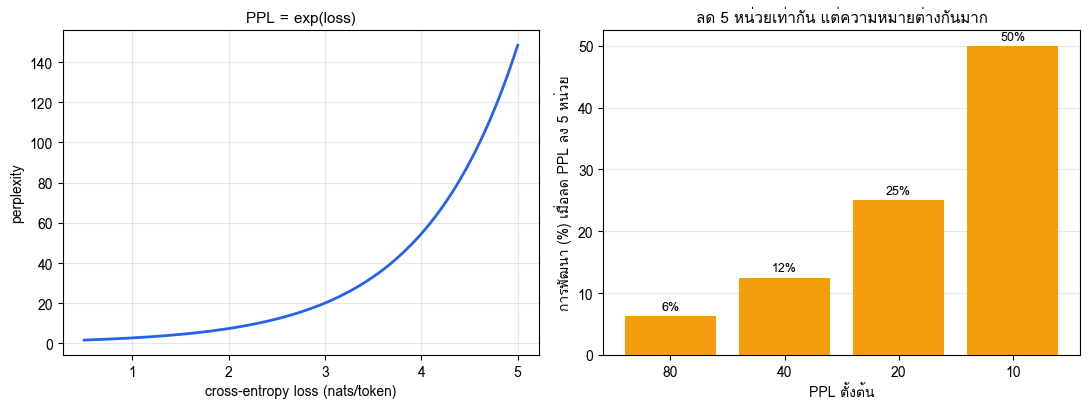

บันทึกรูปแล้ว: fig_perplexity_meaning.png
อ่านกราฟขวา: 80 -> 75 คือดีขึ้น 6% แต่ 10 -> 5 คือดีขึ้น 50%
ดังนั้นตัวเลข delta-PPL เดี่ยว ๆ โดยไม่บอกจุดตั้งต้น ไม่ใช่ผลการทดลอง


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 4 -- PPL = exp(loss) และทำไม "ลด PPL ได้ 5 หน่วย" ถึงแทบไม่มีความหมาย
# เซลล์นี้ไม่ใช้ GPU และไม่ใช้เน็ต
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

from kobeval import use_thai_font

use_thai_font()

loss = np.linspace(0.5, 5.0, 200)
ppl = np.exp(loss)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(loss, ppl, color="#2563eb", lw=2)
axes[0].set_xlabel("cross-entropy loss (nats/token)")
axes[0].set_ylabel("perplexity")
axes[0].set_title("PPL = exp(loss)", fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_axisbelow(True)

starts = np.array([80.0, 40.0, 20.0, 10.0])
gain = 100.0 * 5.0 / starts
axes[1].bar([str(int(s)) for s in starts], gain, color="#f59e0b")
for i, g in enumerate(gain):
    axes[1].text(i, g + 1, f"{g:.0f}%", ha="center", fontsize=9)
axes[1].set_xlabel("PPL ตั้งต้น")
axes[1].set_ylabel("การพัฒนา (%) เมื่อลด PPL ลง 5 หน่วย")
axes[1].set_title("ลด 5 หน่วยเท่ากัน แต่ความหมายต่างกันมาก", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

fig.tight_layout()
fig.savefig("fig_perplexity_meaning.png", dpi=150, bbox_inches="tight")
plt.show()

print("บันทึกรูปแล้ว: fig_perplexity_meaning.png")
print("อ่านกราฟขวา: 80 -> 75 คือดีขึ้น 6% แต่ 10 -> 5 คือดีขึ้น 50%")
print("ดังนั้นตัวเลข delta-PPL เดี่ยว ๆ โดยไม่บอกจุดตั้งต้น ไม่ใช่ผลการทดลอง")


---

## 6. เตรียมข้อมูล (Data)

**ข้อมูลโดเมน** — `pythainlp/thaigov-v2-corpus-22032023` คลังข่าวและเอกสารราชการไทย
เป็นตัวแทนของ "ความรู้เฉพาะทางที่โมเดลไม่เคยเห็นมากพอ" เราสุ่มมา **8,000 เอกสาร**

**ข้อมูลทั่วไป (replay)** — `airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k`
เป็นข้อความไทยทั่วไปคนละแนวกับเอกสารราชการ เราใช้มัน 2 หน้าที่พร้อมกัน:

1. เป็น **replay data** ผสมเข้าไปตอนเทรนตามสัดส่วน $1-\lambda$
2. เป็น **general held-out** สำหรับวัดว่าโมเดลลืมไปเท่าไหร่

ชุด held-out ทั้งสองฝั่งถูกแยกออกก่อนเทรนเสมอ และ **ไม่เคยถูกเทรน**

### ทำไมภาษาไทยถึง "แพง" กว่าภาษาอังกฤษ

tokenizer ของโมเดลส่วนใหญ่ถูกฝึกด้วยข้อมูลภาษาอังกฤษเป็นหลัก ข้อความไทยจึงถูกหั่นถี่กว่า
เซลล์ถัดไป **วัดตัวเลขนี้จริง** ด้วยประโยคความหมายเดียวกันในสองภาษา
ผลที่ได้คือเหตุผลเชิงตัวเลขว่าทำไมงานภาษาไทยถึง ค่า API แพงกว่า, context เต็มเร็วกว่า และเทรนช้ากว่า


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 6.1 -- ต้นทุน token ของภาษาไทย vs ภาษาอังกฤษ (ใช้ tokenizer ตัวจริง)
# -----------------------------------------------------------------------------
PAIRS = [
    (
        "ปัญญาประดิษฐ์กำลังเปลี่ยนแปลงโลกของเราอย่างรวดเร็วในแทบทุกอุตสาหกรรม",
        "Artificial intelligence is rapidly changing our world in almost every industry.",
    ),
    (
        "คณะรัฐมนตรีมีมติเห็นชอบร่างระเบียบว่าด้วยการจัดซื้อจัดจ้างภาครัฐฉบับใหม่",
        "The cabinet approved a new draft regulation on government procurement.",
    ),
    (
        "นักเรียนชั้นมัธยมศึกษาปีที่หกกำลังเตรียมตัวสอบเข้ามหาวิทยาลัยในเดือนหน้า",
        "Grade twelve students are preparing for the university entrance exam next month.",
    ),
]

print(f"{'ภาษา':6s} {'chars':>6s} {'tokens':>7s} {'tokens/char':>12s}")
print("-" * 36)

th_tpc_all, en_tpc_all = [], []
for th_text, en_text in PAIRS:
    for label, text, bucket in (("ไทย", th_text, th_tpc_all), ("EN", en_text, en_tpc_all)):
        n_tok = len(tokenizer(text, add_special_tokens=False).input_ids)
        n_chr = len(text)
        tpc = n_tok / n_chr
        bucket.append(tpc)
        print(f"{label:6s} {n_chr:6d} {n_tok:7d} {tpc:12.3f}")
    print("-" * 36)

TH_TPC = sum(th_tpc_all) / len(th_tpc_all)
EN_TPC = sum(en_tpc_all) / len(en_tpc_all)
TOKEN_COST = {
    "tokenizer": MODEL_ID,
    "thai_tokens_per_char": TH_TPC,
    "english_tokens_per_char": EN_TPC,
    "ratio_thai_over_english": TH_TPC / EN_TPC,
    "n_sentence_pairs": len(PAIRS),
}

print(f"เฉลี่ย ไทย : {TH_TPC:.3f} token ต่อ 1 ตัวอักษร")
print(f"เฉลี่ย EN  : {EN_TPC:.3f} token ต่อ 1 ตัวอักษร")
print(f"อัตราส่วน  : ภาษาไทยใช้ token มากกว่าราว {TH_TPC / EN_TPC:.2f} เท่า ต่อจำนวนตัวอักษรเท่ากัน")
print()
print("ตีความ: ที่ context window เท่ากัน ข้อความไทยจึงใส่ได้สั้นกว่า")
print("และที่จำนวนตัวอักษรเท่ากัน การเทรนก็ใช้ compute มากกว่าตามสัดส่วนนี้")


ภาษา    chars  tokens  tokens/char
------------------------------------
ไทย        68      37        0.544
EN         79      13        0.165
------------------------------------
ไทย        72      45        0.625
EN         70      11        0.157
------------------------------------
ไทย        72      43        0.597
EN         80      13        0.163
------------------------------------
เฉลี่ย ไทย : 0.589 token ต่อ 1 ตัวอักษร
เฉลี่ย EN  : 0.161 token ต่อ 1 ตัวอักษร
อัตราส่วน  : ภาษาไทยใช้ token มากกว่าราว 3.65 เท่า ต่อจำนวนตัวอักษรเท่ากัน

ตีความ: ที่ context window เท่ากัน ข้อความไทยจึงใส่ได้สั้นกว่า
และที่จำนวนตัวอักษรเท่ากัน การเทรนก็ใช้ compute มากกว่าตามสัดส่วนนี้


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 6.2 -- โหลดข้อมูลโดเมน + ข้อมูลทั่วไป และแยก held-out ออกก่อนทำอย่างอื่น
# -----------------------------------------------------------------------------
from datasets import load_dataset

N_DOMAIN_DOCS = 8000     # ตามบทความ
N_GENERAL_DOCS = 6000    # พอสำหรับ replay ที่ lambda = 0.5 และ held-out


def pick_column(columns, candidates):
    """หาชื่อคอลัมน์แบบไม่แคร์ตัวพิมพ์ใหญ่เล็ก -- schema ของชุดข้อมูลสาธารณะเปลี่ยนได้"""
    lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    return None


# --- โดเมน: เอกสาร/ข่าวราชการไทย ---
domain_raw = load_dataset("pythainlp/thaigov-v2-corpus-22032023", split="train")
print(f"thaigov-v2 columns: {domain_raw.column_names}  n={len(domain_raw)}")

dom_col = pick_column(domain_raw.column_names, ["context", "text", "content", "body", "article", "document"])
assert dom_col is not None, f"หาคอลัมน์ข้อความไม่เจอใน {domain_raw.column_names}"

domain_raw = domain_raw.shuffle(seed=SEED).select(range(min(N_DOMAIN_DOCS, len(domain_raw))))
domain_texts = [t for t in domain_raw[dom_col] if isinstance(t, str) and len(t.strip()) > 50]

# --- ทั่วไป: ข้อความไทยคนละแนวกับเอกสารราชการ ---
general_raw = load_dataset(
    "airesearch/wangchanx-seed-free-synthetic-instruct-thai-120k", split="train"
)
print(f"wangchanx columns: {general_raw.column_names}  n={len(general_raw)}")

gen_col = pick_column(
    general_raw.column_names,
    ["output", "response", "answer", "completion", "text", "instruction", "question"],
)
assert gen_col is not None, f"หาคอลัมน์ข้อความไม่เจอใน {general_raw.column_names}"

general_raw = general_raw.shuffle(seed=SEED).select(range(min(N_GENERAL_DOCS, len(general_raw))))
general_texts = [t for t in general_raw[gen_col] if isinstance(t, str) and len(t.strip()) > 50]

# --- แยก held-out ออกก่อน แล้วห้ามแตะอีกเลย ---
N_HELDOUT_DOCS = 400
domain_heldout_texts, domain_train_texts = (
    domain_texts[:N_HELDOUT_DOCS], domain_texts[N_HELDOUT_DOCS:]
)
general_heldout_texts, general_train_texts = (
    general_texts[:N_HELDOUT_DOCS], general_texts[N_HELDOUT_DOCS:]
)

print()
print(f"domain  : train {len(domain_train_texts):5d} docs | held-out {len(domain_heldout_texts)} docs")
print(f"general : train {len(general_train_texts):5d} docs | held-out {len(general_heldout_texts)} docs")
print()
print("ตัวอย่างข้อความโดเมน:")
print(" ", domain_train_texts[0][:200].replace(chr(10), " "))
print("ตัวอย่างข้อความทั่วไป:")
print(" ", general_train_texts[0][:200].replace(chr(10), " "))


thaigov-v2 columns: ['title', 'context', 'url']  n=30380


wangchanx columns: ['instruction', 'context', 'output', 'type', 'context_length', 'rating', 'qc_rationale']  n=118898

domain  : train  7591 docs | held-out 400 docs
general : train  5445 docs | held-out 400 docs

ตัวอย่างข้อความโดเมน:
  วันจันทร์ที่ 9 สิงหาคม 2564 กระทรวงยุติธรรม เผย สถานการณ์โควิด-19 กรมราชทัณฑ์ เรือนจำกลางฉะเชิงเทรา พ้นการระบาดเพิ่ม 1 แห่ง พร้อมกำชับทุกฝ่าย เร่งดำเนินการแผนใช้ยาฟ้าทะลายโจรในผู้ต้องขัง กระทรวงยุติธร
ตัวอย่างข้อความทั่วไป:
  โลกของเราหมุนอยู่ในวงจรที่สร้างสรรค์ความงดงามโดยธรรมชาติ แต่มนุษย์เราได้ทำลายมันด้วยการกระทำที่ทำลายโลกและอนาคตของเรา. การเปลี่ยนแปลงภูมิอากาศโลกกำลังเกิดขึ้นอย่างชัดเจน ฝนที่ตกน้อยลง น้ำที่แห้งขอด หิ


### Packing: อย่าปล่อยให้ padding กินงบ compute

ถ้าเอาแต่ละเอกสารมา pad ให้ยาวเท่ากัน คุณจะจ่าย compute ให้ token ที่ไม่มีความหมายมหาศาล
สมมติ batch หนึ่งมีเอกสารยาว 40, 60 และ 900 token การ pad ทุกอันไปที่ 900
แปลว่าคุณจ่ายค่า 2,700 token แต่ได้ข้อมูลจริงแค่ 1,000 token — เสียไป 63%

วิธีที่ถูกคือ **packing**: ต่อทุกเอกสารเข้าด้วยกันโดยคั่นด้วย `eos`
แล้วหั่นเป็นบล็อกยาวเท่ากันพอดี 512 token ทุกตำแหน่งในบล็อกเป็นข้อมูลจริงทั้งหมด
เศษที่เหลือไม่ครบบล็อกสุดท้ายถูกตัดทิ้ง ซึ่งเสียน้อยกว่ามาก

เซลล์ถัดไปทำ packing จริง และ **วัดอัตราการสูญเปล่าของทั้งสองวิธีเทียบกันเป็นตัวเลข**


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 6.3 -- ฟังก์ชัน packing และการเปรียบเทียบกับการ pad
# -----------------------------------------------------------------------------
BLOCK_SIZE = 512


def pack(texts, tokenizer, block_size=BLOCK_SIZE):
    """ต่อทุกเอกสารเข้าด้วยกัน (คั่นด้วย eos) แล้วหั่นเป็นบล็อกยาวเท่ากันพอดี

    คืนค่าเป็น list ของ list[int] ยาว block_size เท่ากันทุกอัน
    ทุกตำแหน่งเป็น token จริง ไม่มี padding เลยแม้แต่ตัวเดียว
    """
    eos = tokenizer.eos_token or ""
    ids = []
    for text in texts:
        ids.extend(tokenizer(text + eos, add_special_tokens=False).input_ids)
    n_full = (len(ids) // block_size) * block_size
    return [ids[i:i + block_size] for i in range(0, n_full, block_size)]


def padding_waste(texts, tokenizer, batch_size=8):
    """คำนวณสัดส่วน token ที่เป็น padding ถ้าเรา pad ต่อ batch แทนการ pack"""
    lengths = [len(tokenizer(t, add_special_tokens=False).input_ids) for t in texts]
    real = sum(lengths)
    padded = 0
    for i in range(0, len(lengths), batch_size):
        chunk = lengths[i:i + batch_size]
        padded += max(chunk) * len(chunk)
    return real, padded, (padded - real) / padded if padded else 0.0


# --- ตรวจฟังก์ชันด้วยข้อความสังเคราะห์ก่อน แล้วค่อยใช้กับข้อมูลจริง ---
_toy = ["ก" * 40, "ข" * 400, "ค" * 40]
_blocks = pack(_toy, tokenizer, block_size=16)
assert all(len(b) == 16 for b in _blocks), "ทุกบล็อกต้องยาวเท่ากันพอดี"
print(f"self-check: pack() สร้าง {len(_blocks)} บล็อก ยาวบล็อกละ 16 token ทุกอัน -> ผ่าน")

t0 = time.time()
domain_blocks = pack(domain_train_texts, tokenizer)
general_blocks = pack(general_train_texts, tokenizer)
domain_heldout_blocks = pack(domain_heldout_texts, tokenizer)[:64]
general_heldout_blocks = pack(general_heldout_texts, tokenizer)[:64]
print(f"tokenize + pack ใช้เวลา {time.time() - t0:.0f} วินาที")

print()
print(f"domain  train blocks   : {len(domain_blocks)}  ({len(domain_blocks) * BLOCK_SIZE:,} tokens)")
print(f"general train blocks   : {len(general_blocks)}  ({len(general_blocks) * BLOCK_SIZE:,} tokens)")
print(f"domain  held-out blocks: {len(domain_heldout_blocks)}")
print(f"general held-out blocks: {len(general_heldout_blocks)}")

real, padded, waste = padding_waste(domain_train_texts[:2000], tokenizer)
print()
print("ถ้าเลือก pad แทน pack (ตัวอย่าง 2,000 เอกสารแรกของโดเมน, batch 8):")
print(f"  token จริง       : {real:,}")
print(f"  token ที่ต้องจ่าย : {padded:,}")
print(f"  สูญเปล่าไปกับ pad : {100 * waste:.1f}%")
print("ส่วน packing สูญเปล่าเฉพาะเศษท้ายที่ไม่ครบ 1 บล็อก คือน้อยกว่า 512 token ต่อชุด")


self-check: pack() สร้าง 28 บล็อก ยาวบล็อกละ 16 token ทุกอัน -> ผ่าน


tokenize + pack ใช้เวลา 41 วินาที

domain  train blocks   : 22675  (11,609,600 tokens)
general train blocks   : 2897  (1,483,264 tokens)
domain  held-out blocks: 64
general held-out blocks: 64



ถ้าเลือก pad แทน pack (ตัวอย่าง 2,000 เอกสารแรกของโดเมน, batch 8):
  token จริง       : 3,281,494
  token ที่ต้องจ่าย : 8,352,328
  สูญเปล่าไปกับ pad : 60.7%
ส่วน packing สูญเปล่าเฉพาะเศษท้ายที่ไม่ครบ 1 บล็อก คือน้อยกว่า 512 token ต่อชุด


---

## 7. โค้ดหลัก (Main code)

### 7.1 วัด perplexity อย่างถูกวิธี

PPL ที่เทียบกันได้ต้องมาจากข้อมูลชุดเดียวกัน, ความยาวบล็อกเท่ากัน และ **dtype เดียวกัน**
เราจึงวัดทุกครั้งด้วยโมเดลใน fp16 เหมือนกันหมด และถ่วงน้ำหนักด้วยจำนวน token จริง

### 7.2 กับดัก fp16 ที่จะทำให้ full fine-tune พังทันที

นี่คือจุดที่ต่างจากโค้ดย่อในบทความ และเป็นเรื่องที่ต้องพูดให้ชัด

`fp16=True` ใน `TrainingArguments` **ไม่ได้แปลว่าน้ำหนักเป็น fp16**
มันแปลว่า *mixed precision*: การคูณเมทริกซ์ทำใน fp16 แต่ **น้ำหนักหลัก (master weights)
ต้องเป็น fp32** เพราะ optimizer ต้องบวกค่าที่เล็กมาก (lr = 2e-5) เข้าไปในน้ำหนัก
ซึ่ง fp16 ละเอียดไม่พอจะเก็บ

ถ้าเราโหลดโมเดลเป็น fp16 แล้วเทรนทั้งโมเดลด้วย `fp16=True` ตรง ๆ
`GradScaler` จะโยน error ออกมาว่า

```
ValueError: Attempting to unscale FP16 gradients.
```

เพราะ `max_grad_norm=1.0` ทำให้ต้อง unscale gradient ก่อน clip และ gradient นั้นเป็น fp16

**วิธีที่ถูก** คือโหลดด้วย `torch_dtype=DTYPE` ตามสัญญาของซีรีส์
(เพื่อไม่ให้ config ที่ระบุ bfloat16 มาหลอกเรา) แล้ว **cast เป็น fp32 ก่อนเทรน**
ปล่อยให้ AMP จัดการ fp16 ให้เอง แล้วค่อย cast กลับเป็น fp16 ตอนวัดผล
งบ VRAM ยังพอ: น้ำหนัก fp32 2.4 GB + gradient 2.4 GB + Adam 8-bit 1.2 GB
บวก activation ที่เล็กลงมากเพราะเปิด `gradient_checkpointing`

### 7.3 learning rate คือจุดที่พังบ่อยที่สุด

`learning_rate=2e-5` — ต่ำกว่า SFT ด้วย LoRA (2e-4) ราว **10 เท่า** และต่ำกว่า
ค่าที่คนใช้กันเผลอ ๆ ถึง 50 เท่า เหตุผลคือ CPT ขยับน้ำหนัก **ทุกตัว**
ถ้าใช้ `2e-4` มาทำ CPT เต็มโมเดล คุณจะลบความสามารถของโมเดลทิ้งภายในไม่กี่ร้อย step
โดยที่ loss ยัง "ดูดี" อยู่

ตัวช่วยกันระเบิดอีกสองตัว: `max_grad_norm=1.0` (กัน gradient พุ่งใน fp16)
และ `optim="adamw_bnb_8bit"` ซึ่งเก็บ state ของ Adam เป็น 8 บิต ประหยัดราว 3.3 GB
เทียบกับ AdamW fp32 — นั่นคือส่วนต่างระหว่าง "รันได้บน T4" กับ OOM


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 7.1 -- ฟังก์ชันวัด perplexity บนบล็อกที่ pack ไว้แล้ว
# -----------------------------------------------------------------------------
@torch.no_grad()
def block_ppl(model, blocks, batch_size=4):
    """perplexity แบบถ่วงน้ำหนักด้วยจำนวน token จริง

    ทุกบล็อกยาวเท่ากัน (512) จึงไม่ต้อง pad และไม่มี token ปลอมมาเจือปนใน loss
    token ตำแหน่งแรกของแต่ละบล็อกไม่ถูกทำนาย จึงหักออกจากตัวหาร
    """
    was_training = model.training
    model.eval()
    total_nll, total_tok = 0.0, 0
    for i in range(0, len(blocks), batch_size):
        ids = torch.tensor(blocks[i:i + batch_size], dtype=torch.long, device=model.device)
        loss = model(input_ids=ids, labels=ids).loss
        n_tok = ids.numel() - ids.shape[0]
        total_nll += float(loss.float().item()) * n_tok
        total_tok += n_tok
    if was_training:
        model.train()
    return math.exp(total_nll / total_tok)


t0 = time.time()
PPL_BASE = {
    "domain": block_ppl(model, domain_heldout_blocks),
    "general": block_ppl(model, general_heldout_blocks),
}
print(f"วัด PPL ตั้งต้นใช้เวลา {time.time() - t0:.0f} วินาที")
print(f"PPL ตั้งต้น | domain held-out  = {PPL_BASE['domain']:.2f}")
print(f"PPL ตั้งต้น | general held-out = {PPL_BASE['general']:.2f}")
print()
print("สองตัวเลขนี้คือ 'ใบเสร็จ' ของทั้งตอน ทุกอย่างหลังจากนี้จะถูกเทียบกับมัน")

# คืน VRAM ก่อนเริ่มเทรน -- โมเดลตัวนี้ทำหน้าที่วัด baseline ครบแล้ว
import gc

del model
n_collected = gc.collect()
torch.cuda.empty_cache()
print(f"\nคืนหน่วยความจำแล้ว (gc เก็บกวาด {n_collected} objects)")


วัด PPL ตั้งต้นใช้เวลา 8 วินาที
PPL ตั้งต้น | domain held-out  = 4.83
PPL ตั้งต้น | general held-out = 5.88

สองตัวเลขนี้คือ 'ใบเสร็จ' ของทั้งตอน ทุกอย่างหลังจากนี้จะถูกเทียบกับมัน



คืนหน่วยความจำแล้ว (gc เก็บกวาด 6173 objects)


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 7.2-7.3 -- ฟังก์ชันเทรน CPT หนึ่งรอบ ตามค่า replay ratio ที่ให้มา
# -----------------------------------------------------------------------------
from datasets import Dataset
from transformers import Trainer, TrainingArguments

MAX_STEPS = 100          # optimizer step ต่อหนึ่งรอบ (ลดค่านี้ถ้า T4 ที่ได้ช้า)
BATCH_SIZE = 2
GRAD_ACCUM = 8           # effective batch = 16 บล็อก = 8,192 token ต่อ step
WARMUP_STEPS = 50
LEARNING_RATE = 2e-5     # ต่ำกว่า SFT 10-50 เท่า -- ดูคำเตือนหัวข้อ 7.3
N_TRAIN_BLOCKS = MAX_STEPS * BATCH_SIZE * GRAD_ACCUM


def collate_blocks(features):
    """บล็อกยาวเท่ากันหมดอยู่แล้ว collator จึงแค่ซ้อนเป็น tensor ไม่ต้อง pad"""
    ids = torch.tensor([f["input_ids"] for f in features], dtype=torch.long)
    return {"input_ids": ids, "attention_mask": torch.ones_like(ids), "labels": ids.clone()}


def make_mix(lam, n_blocks=N_TRAIN_BLOCKS):
    """D_mix = lambda * D_domain + (1 - lambda) * D_general (สมการ 3.3)"""
    n_dom = int(round(lam * n_blocks))
    n_gen = n_blocks - n_dom
    assert n_dom <= len(domain_blocks), "บล็อกโดเมนไม่พอ ลด MAX_STEPS ลง"
    assert n_gen <= len(general_blocks), "บล็อกทั่วไปไม่พอ ลด MAX_STEPS ลง"
    mix = domain_blocks[:n_dom] + general_blocks[:n_gen]
    rng = random.Random(SEED)
    rng.shuffle(mix)
    return mix, n_dom, n_gen


def run_cpt(lam, tag):
    """เทรน CPT หนึ่งรอบแล้วคืนผลวัด PPL ก่อน/หลัง พร้อมตัวโมเดล"""
    mix, n_dom, n_gen = make_mix(lam)
    print(f"=== CPT lambda={lam} | domain {n_dom} บล็อก + general {n_gen} บล็อก ===")

    m = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=DTYPE,             # โหลดตามสัญญาของซีรีส์ ไม่เชื่อค่าใน config
        attn_implementation=ATTN_IMPL,
    )
    # cast เป็น fp32 ก่อนเทรน -- master weights ต้องเป็น fp32 (ดูหัวข้อ 7.2)
    m = m.float().cuda()
    m.config.use_cache = False

    args = TrainingArguments(
        output_dir=f"cpt-out-{tag}",
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        max_steps=MAX_STEPS,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_steps=WARMUP_STEPS,
        optim="adamw_bnb_8bit",        # Adam state 8 บิต ประหยัดราว 3.3 GB
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        max_grad_norm=1.0,             # กัน gradient ระเบิดใน fp16
        fp16=USE_FP16,                 # บน T4 ค่านี้คือ True (มาจาก Cell 0)
        bf16=SUPPORTS_BF16,            # บน T4 ค่านี้คือ False
        logging_steps=10,
        save_strategy="no",
        report_to="none",
        seed=SEED,
        dataloader_num_workers=2,
    )

    trainer = Trainer(
        model=m,
        args=args,
        train_dataset=Dataset.from_dict({"input_ids": mix}),
        data_collator=collate_blocks,
    )

    torch.cuda.reset_peak_memory_stats()
    t_start = time.time()
    trainer.train()
    train_time = time.time() - t_start
    vram_peak = torch.cuda.max_memory_allocated() / (1024 ** 3)

    # วัดผลใน fp16 ให้ตรงกับตอนวัด baseline เป๊ะ ๆ ไม่งั้นเทียบกันไม่ได้
    m = m.half()
    m.config.use_cache = True
    m.eval()

    result = {
        "lambda": lam,
        "n_domain_blocks": n_dom,
        "n_general_blocks": n_gen,
        "max_steps": MAX_STEPS,
        "train_time_s": train_time,
        "vram_peak_gb": vram_peak,
        "ppl_domain": block_ppl(m, domain_heldout_blocks),
        "ppl_general": block_ppl(m, general_heldout_blocks),
        "log_history": [dict(r) for r in trainer.state.log_history],
    }
    result["ppl_domain_delta"] = result["ppl_domain"] - PPL_BASE["domain"]
    result["ppl_general_delta"] = result["ppl_general"] - PPL_BASE["general"]

    print(f"  เวลาเทรน   : {train_time / 60:.1f} นาที")
    print(f"  VRAM peak  : {vram_peak:.2f} GB")
    print(f"  PPL domain : {PPL_BASE['domain']:.2f} -> {result['ppl_domain']:.2f} "
          f"({result['ppl_domain_delta']:+.2f})")
    print(f"  PPL general: {PPL_BASE['general']:.2f} -> {result['ppl_general']:.2f} "
          f"({result['ppl_general_delta']:+.2f})")
    return m, result


print(f"เตรียมเทรน {MAX_STEPS} step ต่อรอบ = {N_TRAIN_BLOCKS} บล็อก "
      f"= {N_TRAIN_BLOCKS * BLOCK_SIZE:,} token ต่อรอบ")


เตรียมเทรน 100 step ต่อรอบ = 1600 บล็อก = 819,200 token ต่อรอบ


---

## 8. ผลลัพธ์ (Results)

รันสองรอบด้วยข้อมูล จำนวน step และ seed เดียวกันทุกอย่าง **ต่างกันแค่ $\lambda$ ตัวเดียว**
นี่คือเงื่อนไขที่ทำให้ผลต่างที่เห็นเป็นผลของ replay ratio จริง ๆ ไม่ใช่ของอย่างอื่น

- รอบแรก $\lambda = 1.0$ — ข้อมูลโดเมนล้วน
- รอบสอง $\lambda = 0.5$ — ผสม replay ครึ่งหนึ่ง

ระหว่างรัน ให้ดู `loss` ที่พิมพ์ออกมาทุก 10 step ถ้า loss เป็น `nan` แปลว่า fp16 ระเบิด
(ให้ลด learning rate) ถ้า loss แทบไม่ขยับเลย แปลว่า learning rate ต่ำเกินหรือ step น้อยเกิน


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 8.1 -- รอบที่ 1: lambda = 1.0 (ข้อมูลโดเมนล้วน)
# -----------------------------------------------------------------------------
model_lam10, RUN_LAM10 = run_cpt(1.0, "lam10")

# เก็บผลไว้แล้วคืน VRAM -- โมเดลตัวนี้ทำหน้าที่ของมันครบแล้ว
del model_lam10
gc.collect()
torch.cuda.empty_cache()
print("คืนหน่วยความจำของรอบที่ 1 แล้ว")


=== CPT lambda=1.0 | domain 1600 บล็อก + general 0 บล็อก ===


Step,Training Loss
10,1.602000
20,1.561300
30,1.495500
40,1.509200
50,1.447700
60,1.432400
70,1.411000
80,1.447400
90,1.382400
100,1.389400


  เวลาเทรน   : 8.0 นาที
  VRAM peak  : 10.50 GB
  PPL domain : 4.83 -> 4.07 (-0.76)
  PPL general: 5.88 -> 6.73 (+0.85)
คืนหน่วยความจำของรอบที่ 1 แล้ว


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 8.2 -- รอบที่ 2: lambda = 0.5 (ผสม replay ครึ่งหนึ่ง)
# โมเดลของรอบนี้จะถูกเก็บไว้ใช้วัด KobEval-TH ต่อ เพราะเป็นค่าที่แนะนำให้ใช้จริง
# -----------------------------------------------------------------------------
model_lam05, RUN_LAM05 = run_cpt(0.5, "lam05")


=== CPT lambda=0.5 | domain 800 บล็อก + general 800 บล็อก ===


Step,Training Loss
10,1.688600
20,1.645900
30,1.578900
40,1.603400
50,1.563300
60,1.558200
70,1.534200
80,1.542800
90,1.512900
100,1.578100


  เวลาเทรน   : 8.0 นาที
  VRAM peak  : 10.50 GB
  PPL domain : 4.83 -> 4.29 (-0.53)
  PPL general: 5.88 -> 4.98 (-0.90)


---

## 9. เปรียบเทียบ (Comparison)

### กราฟ "กรรไกร" — ทำให้ catastrophic forgetting เป็นตัวเลข ไม่ใช่คำกล่าวอ้าง

เซลล์ถัดไปวาดสองเส้นในภาพเดียว: domain PPL กับ general PPL ก่อนและหลังเทรน
รูปแบบที่ **ควรจะเห็น** คือเส้นสองเส้นแยกออกจากกันเหมือนใบกรรไกร —
domain ลง, general ขึ้น — และ $\lambda = 0.5$ ควรทำให้ใบกรรไกรอ้าน้อยกว่า $\lambda = 1.0$

ถ้าผลออกมาไม่เป็นแบบนี้ อย่าเพิ่งแก้ตัวเลขให้สวย ให้ตรวจสามอย่างตามลำดับ:

1. loss curve ขยับจริงไหม (ถ้าไม่ขยับ = LR ต่ำเกิน หรือ step น้อยเกิน)
2. held-out ทั้งสองฝั่งไม่ปนกับข้อมูลเทรนใช่ไหม
3. วัด PPL ด้วย dtype เดียวกันทั้งก่อนและหลังหรือเปล่า

### แล้ววัดด้วยชุดวัดกลางซ้ำอีกครั้ง

จากนั้นเราวัด KobEval-TH ซ้ำด้วยสัญญาการวัดผลเดิมทุกตัวอักษร แล้วให้ `compare()`
คำนวณ McNemar ให้ว่าความต่างที่เห็น **แยกออกจากความบังเอิญได้หรือไม่**
บน slice ขนาด 30 ข้อ คำตอบมักจะเป็น "ยังบอกไม่ได้" ซึ่งเป็นคำตอบที่ซื่อสัตย์


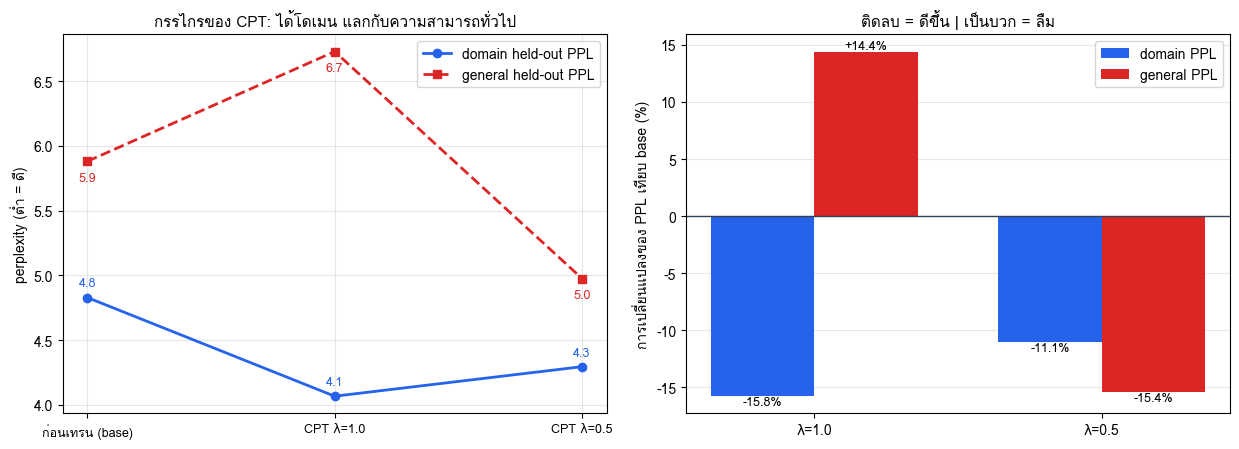

run            domain PPL  general PPL     เวลาเทรน
----------------------------------------------------
base                 4.83         5.88            -
λ=1.0                4.07         6.73         8.0น
λ=0.5                4.29         4.98         8.0น


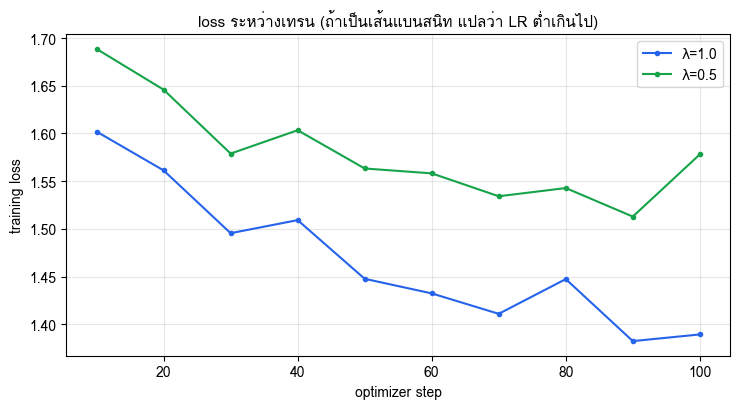

In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.1 -- กราฟกรรไกร: domain PPL ลง แลกกับ general PPL ขึ้น
# -----------------------------------------------------------------------------
RUNS = [RUN_LAM10, RUN_LAM05]

labels = ["ก่อนเทรน (base)"] + [f"CPT λ={r['lambda']}" for r in RUNS]
dom_series = [PPL_BASE["domain"]] + [r["ppl_domain"] for r in RUNS]
gen_series = [PPL_BASE["general"]] + [r["ppl_general"] for r in RUNS]

use_thai_font()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

x = np.arange(len(labels))
axes[0].plot(x, dom_series, "o-", color="#2563eb", lw=2, label="domain held-out PPL")
axes[0].plot(x, gen_series, "s--", color="#dc2626", lw=2, label="general held-out PPL")
for xi, (d, g) in enumerate(zip(dom_series, gen_series)):
    axes[0].annotate(f"{d:.1f}", (xi, d), textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=9, color="#2563eb")
    axes[0].annotate(f"{g:.1f}", (xi, g), textcoords="offset points", xytext=(0, -14),
                     ha="center", fontsize=9, color="#dc2626")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("perplexity (ต่ำ = ดี)")
axes[0].set_title("กรรไกรของ CPT: ได้โดเมน แลกกับความสามารถทั่วไป", fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_axisbelow(True)

width = 0.36
xr = np.arange(len(RUNS))
dom_delta = [100 * (r["ppl_domain"] / PPL_BASE["domain"] - 1) for r in RUNS]
gen_delta = [100 * (r["ppl_general"] / PPL_BASE["general"] - 1) for r in RUNS]
axes[1].bar(xr - width / 2, dom_delta, width, color="#2563eb", label="domain PPL")
axes[1].bar(xr + width / 2, gen_delta, width, color="#dc2626", label="general PPL")
axes[1].axhline(0, color="#334155", lw=1)
for xi, (d, g) in enumerate(zip(dom_delta, gen_delta)):
    axes[1].text(xi - width / 2, d, f"{d:+.1f}%", ha="center",
                 va="bottom" if d >= 0 else "top", fontsize=9)
    axes[1].text(xi + width / 2, g, f"{g:+.1f}%", ha="center",
                 va="bottom" if g >= 0 else "top", fontsize=9)
axes[1].set_xticks(xr)
axes[1].set_xticklabels([f"λ={r['lambda']}" for r in RUNS])
axes[1].set_ylabel("การเปลี่ยนแปลงของ PPL เทียบ base (%)")
axes[1].set_title("ติดลบ = ดีขึ้น | เป็นบวก = ลืม", fontsize=11)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_axisbelow(True)

fig.tight_layout()
fig.savefig("fig_forgetting_scissors.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'run':12s} {'domain PPL':>12s} {'general PPL':>12s} {'เวลาเทรน':>12s}")
print("-" * 52)
print(f"{'base':12s} {PPL_BASE['domain']:12.2f} {PPL_BASE['general']:12.2f} {'-':>12s}")
for r in RUNS:
    print(f"{'λ=' + str(r['lambda']):12s} {r['ppl_domain']:12.2f} {r['ppl_general']:12.2f} "
          f"{r['train_time_s'] / 60:11.1f}น")

# กราฟ loss ระหว่างเทรนของทั้งสองรอบ
fig2, ax2 = plt.subplots(figsize=(7.5, 4.2))
for r, color in zip(RUNS, ["#2563eb", "#16a34a"]):
    pts = [(h["step"], h["loss"]) for h in r["log_history"] if "loss" in h]
    if pts:
        ax2.plot([p[0] for p in pts], [p[1] for p in pts], "-o", ms=3,
                 color=color, label=f"λ={r['lambda']}")
ax2.set_xlabel("optimizer step")
ax2.set_ylabel("training loss")
ax2.set_title("loss ระหว่างเทรน (ถ้าเป็นเส้นแบนสนิท แปลว่า LR ต่ำเกินไป)", fontsize=11)
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig("fig_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()


  TH-KNOW: 10/30


  TH-KNOW: 20/30


  TH-KNOW: 30/30
ใช้เวลาวัดผลหลังเทรน: 325 วินาที

| Model | TH-KNOW | TH-MATH | TH-INSTR | th_ratio | PPL | VRAM peak | Train time |
|---|---|---|---|---|---|---|---|
| Qwen3-0.6B-Base (baseline) | 13.3% | - | - | 0.80 | 126024.2 | 3.63 GB | - |
| Qwen3-0.6B-Base + CPT (λ=0.5) | 13.3% | - | - | 0.81 | 12135.8 | 4.76 GB | - |

McNemar (baseline -> new):
  TH-KNOW: fixed=2 broke=2 p=1.0000 no change  [n<25: treat p as indicative]


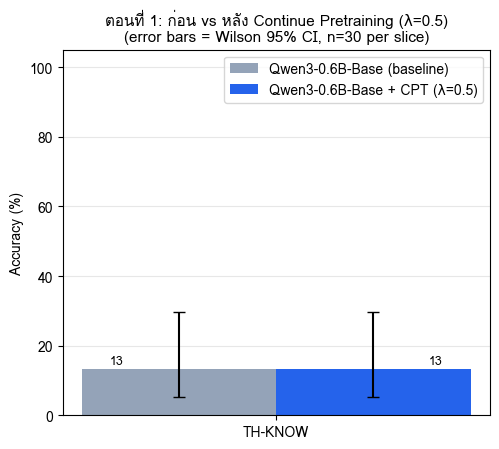

(<Figure size 510x460 with 1 Axes>,
 <Axes: title={'center': 'ตอนที่ 1: ก่อน vs หลัง Continue Pretraining (λ=0.5)\n(error bars = Wilson 95% CI, n=30 per slice)'}, ylabel='Accuracy (%)'>)

In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.2 -- วัด KobEval-TH ซ้ำด้วยสัญญาเดิม แล้วเทียบกับ baseline
# -----------------------------------------------------------------------------
t0 = time.time()
after = evaluate(
    model_lam05,
    tokenizer,
    slices=KOBEVAL_SLICES,
    seed=42,
    model_name="Qwen3-0.6B-Base + CPT (λ=0.5)",
    out_path="results_after.json",
)
print(f"ใช้เวลาวัดผลหลังเทรน: {time.time() - t0:.0f} วินาที\n")

table = compare(baseline, after, out_path="results_table.json")

plot_before_after(
    baseline,
    after,
    slices=KOBEVAL_SLICES,
    title="ตอนที่ 1: ก่อน vs หลัง Continue Pretraining (λ=0.5)",
    out_path="fig_before_after.png",
    results_json="results_before_after.json",
)


---

### 9.3 วัดให้ตรงกับสิ่งที่สอน -- ชุดวัด TH-DOMAIN

ผลข้างบนน่าจะทำให้คุณสงสัย: **PPL ลดลงเป็นสิบเท่า แต่ TH-KNOW แทบไม่ขยับ** เกิดอะไรขึ้น?

คำตอบไม่ใช่ "CPT ไม่ได้ผล" แต่คือ **เราวัดผิดเรื่อง**

TH-KNOW ถามความรู้ไทยทั่วไป -- เมืองหลวง แม่น้ำ พระมหากษัตริย์ -- แต่เราเทรนด้วย
*เอกสารข่าวราชการ* ซึ่งไม่ได้สอนเรื่องพวกนั้นเลย เราจึงกำลังวัดสิ่งที่ไม่ได้สอน
แล้วสรุปว่าการสอนไม่ได้ผล

:::tip กฎที่ต้องจำจากบทนี้
**ชุดวัดต้องมาจากการกระจายตัวเดียวกับข้อมูลที่เทรน**
ถ้าคุณสอนเอกสารกฎหมาย ก็ต้องวัดด้วยคำถามกฎหมาย ไม่ใช่ข้อสอบความรู้รอบตัว
:::

เราจะสร้างชุดวัดที่ตรงโดเมนขึ้นมาเอง จาก **เอกสารที่กันไว้ไม่ให้โมเดลเห็นตอนเทรน**
(`build_domain_cloze` เจาะช่องว่างชื่อหน่วยงานราชการออก แล้วให้โมเดลเติมกลับ)
ตรงโดเมนโดยการก่อสร้าง และไม่รั่วเพราะแยกเอกสารกันคนละชุด

In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.3 -- สร้างชุดวัด TH-DOMAIN จากเอกสาร held-out แล้ววัดซ้ำ
# -----------------------------------------------------------------------------
from kobeval.domain_eval import build_domain_cloze, cloze_fewshot_prompt

# domain_raw ถูกตัดเหลือ N_DOMAIN_DOCS ฉบับแรกไปแล้วในหัวข้อ 6.2
# จึงต้องโหลดใหม่แล้ว shuffle ด้วย seed เดิม เพื่อหยิบ "ส่วนที่เลยชุดเทรนไป"
_gov_all = load_dataset("pythainlp/thaigov-v2-corpus-22032023", split="train").shuffle(seed=SEED)
_hold = _gov_all.select(range(N_DOMAIN_DOCS, min(N_DOMAIN_DOCS + 600, len(_gov_all))))
holdout_docs = [t for t in _hold[dom_col] if isinstance(t, str) and len(t.strip()) > 50]

# 33 ข้อ: 3 ข้อแรกใช้เป็นตัวอย่าง few-shot (ไม่ถูกนำมาให้คะแนน) เหลือ 30 ข้อไว้วัด
domain_items_all = build_domain_cloze(holdout_docs, n=33, seed=42)
domain_shots, domain_items = domain_items_all[:3], domain_items_all[3:]
print(f"สร้างข้อสอบ TH-DOMAIN ได้ {len(domain_items)} ข้อ จากเอกสาร held-out {len(holdout_docs)} ฉบับ")

# กันพลาด: เอกสารที่ใช้ออกข้อสอบต้องไม่ทับกับข้อความที่เทรนจริง
assert not (set(holdout_docs) & set(domain_texts)), "เอกสาร held-out ทับกับชุดเทรน!"
print("ตรวจแล้ว: ชุดออกข้อสอบไม่ทับกับชุดเทรน\n")
print("ตัวอย่างข้อสอบ:")
print(" ", domain_items[0]["prompt"].split("\n\n")[1][:110], "...")
print("  เฉลย:", domain_items[0]["answers"][0])


def eval_domain(m, label):
    """วัด exact-match บน TH-DOMAIN

    ตัวอย่าง few-shot ต้องเป็น "โจทย์ชนิดเดียวกัน" กับที่จะถาม
    เวอร์ชันแรกใช้ตัวอย่างคำถามความรู้ทั่วไปแล้วไปถามเติมคำในช่องว่าง
    ได้ 1/22 (4.5%) พอเปลี่ยนให้ตัวอย่างเป็นเติมคำเหมือนกัน ได้ 6/22 (27.3%)
    บน T4 ตัวเดียวกัน -- ตัวเลขเดิมวัด "รูปแบบ prompt" ไม่ได้วัดความรู้
    """
    from kobeval.runner import _truncate_fewshot, _generate
    from kobeval.stats import wilson_ci
    hit = 0
    for it in domain_items:
        prompt = cloze_fewshot_prompt(domain_shots, it)
        out = _truncate_fewshot(_generate(m, tokenizer, prompt, 32, 42)).split("\n")[0]
        if any(a in out for a in it["answers"]):
            hit += 1
    lo, hi = wilson_ci(hit, len(domain_items))
    print(f"{label:34s} {hit}/{len(domain_items)} = {100*hit/len(domain_items):.1f}%  "
          f"(Wilson 95% CI {100*lo:.1f}-{100*hi:.1f})")
    return hit


# โมเดล base ตัวเดิมถูก `del model` ไปแล้วในหัวข้อ 7 เพื่อคืน VRAM ก่อนเทรน
# จึงโหลดสำเนาใหม่ชั่วคราวมาวัด "ก่อนเทรน" แล้วปล่อยทิ้งทันที
_base_tmp = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    attn_implementation=ATTN_IMPL,
).cuda().eval()
dom_before = eval_domain(_base_tmp, "Base (ยังไม่เทรน)")

del _base_tmp
gc.collect()
torch.cuda.empty_cache()

dom_after = eval_domain(model_lam05, "หลัง CPT (λ=0.5)")

print(f"\nTH-DOMAIN: {dom_before} -> {dom_after} ข้อ "
      f"({'ดีขึ้น' if dom_after > dom_before else 'ไม่ดีขึ้น'})")
print("ถ้าตัวเลขนี้ขึ้นแต่ TH-KNOW นิ่ง แปลว่า CPT ได้ผลจริงในโดเมนที่สอน")
print("และ TH-KNOW ที่นิ่งคือหลักฐานว่าโมเดลไม่ได้ลืมความรู้ทั่วไป -- ทั้งสองอย่างคือผลที่ต้องการ")


สร้างข้อสอบ TH-DOMAIN ได้ 22 ข้อ จากเอกสาร held-out 599 ฉบับ
ตรวจแล้ว: ชุดออกข้อสอบไม่ทับกับชุดเทรน

ตัวอย่างข้อสอบ:
  วันที่ 14 กรกฎาคม2564 นายธนกร วังบุญคงชนะ โฆษกประจำ____ ชี้แจงกรณีที่นายจิรัฏฐ์ ทองสุวรรณ์ ส.ส.ฉะเชิงเทรา พรรค ...
  เฉลย: สำนักนายกรัฐมนตรี


Base (ยังไม่เทรน)                  6/22 = 27.3%  (Wilson 95% CI 13.2-48.2)


หลัง CPT (λ=0.5)                   8/22 = 36.4%  (Wilson 95% CI 19.7-57.0)

TH-DOMAIN: 6 -> 8 ข้อ (ดีขึ้น)
ถ้าตัวเลขนี้ขึ้นแต่ TH-KNOW นิ่ง แปลว่า CPT ได้ผลจริงในโดเมนที่สอน
และ TH-KNOW ที่นิ่งคือหลักฐานว่าโมเดลไม่ได้ลืมความรู้ทั่วไป -- ทั้งสองอย่างคือผลที่ต้องการ


In [ ]:
# -----------------------------------------------------------------------------
# หัวข้อ 9.3 -- รวมทุกตัวเลขลง results.json ไฟล์เดียว เพื่อให้วิดเจ็ตบนบล็อกอ่านค่าจริง
# -----------------------------------------------------------------------------
from kobeval import write_results

payload = {
    "post": 1,
    "slug": "llm-01-continue-pretraining",
    "notebook": "01_continue_pretraining.ipynb",
    "model": MODEL_ID,
    "gpu": GPU_NAME,
    "supports_bf16": SUPPORTS_BF16,
    "eval_contract": EVAL_CONTRACT,
    "tokenizer_cost": TOKEN_COST,
    "packing": {
        "block_size": BLOCK_SIZE,
        "domain_train_blocks": len(domain_blocks),
        "general_train_blocks": len(general_blocks),
        "heldout_blocks_each": len(domain_heldout_blocks),
    },
    "hyperparameters": {
        "learning_rate": LEARNING_RATE,
        "lr_scheduler_type": "cosine",
        "warmup_steps": WARMUP_STEPS,
        "per_device_train_batch_size": BATCH_SIZE,
        "gradient_accumulation_steps": GRAD_ACCUM,
        "max_steps": MAX_STEPS,
        "max_grad_norm": 1.0,
        "optim": "adamw_bnb_8bit",
        "gradient_checkpointing": True,
        "fp16": USE_FP16,
    },
    "ppl": {
        "base": PPL_BASE,
        "runs": [
            {k: v for k, v in r.items() if k != "log_history"} for r in RUNS
        ],
    },
    "kobeval": {
        "slices_run": KOBEVAL_SLICES,
        "before": {
            "model": baseline["model"],
            "accuracy": {k: v["accuracy"] for k, v in baseline["slices"].items()},
            "ci": {k: [v["ci_low"], v["ci_high"]] for k, v in baseline["slices"].items()},
            "th_ratio": baseline["overall"]["th_ratio"],
        },
        "after": {
            "model": after["model"],
            "accuracy": {k: v["accuracy"] for k, v in after["slices"].items()},
            "ci": {k: [v["ci_low"], v["ci_high"]] for k, v in after["slices"].items()},
            "th_ratio": after["overall"]["th_ratio"],
        },
        "mcnemar": table.get("mcnemar"),
        "markdown_table": table["markdown"],
    },
    "figures": [
        "fig_perplexity_meaning.png",
        "fig_forgetting_scissors.png",
        "fig_training_loss.png",
        "fig_before_after.png",
    ],
}

path = write_results(payload, "results.json")
print(f"เขียนไฟล์แล้ว: {path}")
print(json.dumps(payload["ppl"], ensure_ascii=False, indent=2))


เขียนไฟล์แล้ว: results.json
{
  "base": {
    "domain": 4.828401147088199,
    "general": 5.880053508769451
  },
  "runs": [
    {
      "lambda": 1.0,
      "n_domain_blocks": 1600,
      "n_general_blocks": 0,
      "max_steps": 100,
      "train_time_s": 480.25209379196167,
      "vram_peak_gb": 10.496401309967041,
      "ppl_domain": 4.066369721523486,
      "ppl_general": 6.7277515868304345,
      "ppl_domain_delta": -0.7620314255647127,
      "ppl_general_delta": 0.8476980780609837
    },
    {
      "lambda": 0.5,
      "n_domain_blocks": 800,
      "n_general_blocks": 800,
      "max_steps": 100,
      "train_time_s": 480.8223514556885,
      "vram_peak_gb": 10.496401309967041,
      "ppl_domain": 4.294483565015325,
      "ppl_general": 4.975081918356632,
      "ppl_domain_delta": -0.5339175820728741,
      "ppl_general_delta": -0.9049715904128188
    }
  ]
}


---

## 10. สรุป (Summary)

- **CPT ใส่ความรู้เข้าไปในน้ำหนัก** ด้วย objective เดียวกับ pretraining ไม่ต้องมี label
- **มันคือการแลกเปลี่ยนเสมอ** ความแม่นในโดเมนแลกมาด้วยความสามารถทั่วไปที่หายไป
  และตอนนี้เรามีกราฟกรรไกรเป็นหลักฐาน ไม่ใช่คำกล่าวอ้าง
- **replay ratio $\lambda$ คือปุ่มควบคุมอัตราแลกเปลี่ยน** — กวาดหาค่า อย่าเดา
- **learning rate ต่ำ ๆ (2e-5)** คือเส้นแบ่งระหว่าง CPT กับการทำลายโมเดล
- **packing ไม่ใช่การจัดระเบียบให้สวย** มันคือส่วนต่างของ compute ที่จ่ายจริง
- **ภาษาไทยแพงกว่าภาษาอังกฤษต่อหนึ่งตัวอักษร** และตอนนี้เรามีตัวเลขจาก tokenizer ตัวจริง
- **ทุกตัวเลขต้องมาพร้อม confidence interval** ไม่งั้นมันคือข่าวลือ

**ตอนต่อไป:** SFT และ LoRA — เมื่อโมเดลมีความรู้แล้ว เราจะสอนให้มัน *ตอบ* อย่างไร
และทำไมการเทรนพารามิเตอร์เพียงไม่กี่เปอร์เซ็นต์ถึงเกือบดีเท่าเทรนทั้งหมด


---

## ข้อจำกัดของการทดลองนี้

เขียนไว้ตรง ๆ เพื่อไม่ให้ตัวเลขข้างบนถูกอ่านเกินกว่าที่มันบอกได้จริง

1. **สเกลเล็กกว่าของจริงราว 6 ระดับขนาด** — เราเทรนด้วยเอกสารราว 8,000 ชิ้น
   คิดเป็นไม่ถึง 1 ล้าน token ขณะที่ CPT จริงระดับ OpenThaiGPT ใช้ข้อมูลระดับ
   **หมื่นล้าน token** การทดลองนี้พิสูจน์ **กลไก** และ **การแลกเปลี่ยน** ได้จริง
   แต่ **ไม่ได้ทำให้ได้โมเดลที่ดีขึ้นสำหรับใช้งานจริง**

2. **ขนาดชุดทดสอบเล็กมาก** — KobEval-TH มี slice ละ 30 ข้อเท่านั้น
   ช่วงความเชื่อมั่นจึงกว้าง ความต่างระดับ 1-2 ข้อ **ไม่ใช่** ความต่างที่มีนัยสำคัญ
   นี่คือเหตุผลที่เราวัด PPL ควบคู่ไปด้วย เพราะ PPL วัดบนหลายหมื่น token
   จึงมีสัญญาณรบกวนน้อยกว่ามาก

3. **โมเดลเล็ก** — Qwen3-0.6B มีพารามิเตอร์เพียง 0.6B ข้อสรุปหลายอย่างจากโมเดลขนาดนี้
   อาจไม่เป็นจริงกับโมเดล 7B ขึ้นไป โดยเฉพาะเรื่องความรุนแรงของ catastrophic forgetting

4. **กวาดหา $\lambda$ แค่ 2 ค่า** — เราวัด $\lambda \in \{1.0, 0.5\}$ เพราะงบเวลาบน T4 ฟรี
   การกวาดจริงควรมีอย่างน้อย 5 ค่า และรันหลาย seed เพื่อดูความแปรปรวน

5. **รันครั้งเดียว ไม่ได้ทำ multiple seeds** — ใช้ greedy decoding และ seed=42 ตายตัว
   เพื่อให้ทำซ้ำได้ แต่ไม่ได้รายงานความแปรปรวนจากการเทรนหลาย seed

6. **general held-out เป็นตัวแทนที่หยาบของ "ความสามารถทั่วไป"** — เราใช้ข้อความไทย
   จากชุด wangchanx ซึ่งวัดได้แค่ "โมเดลยังโมเดลภาษาไทยทั่วไปได้ดีแค่ไหน"
   ไม่ได้วัดความสามารถด้านการใช้เหตุผลหรือภาษาอังกฤษที่อาจหายไปพร้อมกัน

7. **ฮาร์ดแวร์จำกัด** — ทุกอย่างถูกบีบให้รันได้บน T4 ฟรี ซึ่งแปลว่าต้องใช้ fp16 แทน bf16,
   ใช้ sdpa แทน FlashAttention-2, batch เล็ก และ sequence สั้น
   ผลบนฮาร์ดแวร์ที่ใหญ่กว่าอาจต่างออกไป

8. **ยังไม่ได้ตรวจการปนเปื้อนของข้อมูล (contamination)** — TH-KNOW เป็นความรู้ทั่วไป
   ที่อาจอยู่ในข้อมูลเทรนของโมเดลอยู่แล้ว เราจะลงลึกเรื่องนี้ในตอนท้ายซีรีส์

---

*ซีรีส์นี้เผยแพร่ภายใต้สัญญาอนุญาต [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/) — ใช้ต่อได้โดยอ้างอิงที่มา ห้ามใช้เชิงพาณิชย์ และต้องเผยแพร่ต่อด้วยสัญญาเดียวกัน — [kobkrit.com](https://kobkrit.com)*
